# Method 3 Noise Validation Review

Human-review notebook for Stages 02 and 03. It checks the corrected Stage 02 gate: FITS-derived local patch noise matches HDF5 `intensity_err`, while `image_sigma` is a separate whole-image threshold-like field. It also summarizes the Stage 03 trap-free local-noise map.

In [1]:
from pathlib import Path
import json

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def find_workspace():
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / 'trap_completeness_method3').exists():
            return candidate
    raise RuntimeError('Could not find repo root containing trap_completeness_method3')

root = find_workspace()
workspace = root / 'trap_completeness_method3'
cache = workspace / 'cache'
figures = cache / 'figures'

plt.rcParams['figure.dpi'] = 120
root, cache

(WindowsPath('C:/Users/Ansh/Projects/sensei_charge_traps'),
 WindowsPath('C:/Users/Ansh/Projects/sensei_charge_traps/trap_completeness_method3/cache'))

## Stage 02 Gate

The review target is not that local patch noise equals `image_sigma`. Stage 02 found that local patch noise equals `intensity_err` exactly in the sampled parity rows, and `image_sigma` is a different whole-image quantity.

In [2]:
with (cache / '02_noise_parity_summary.json').open() as f:
    parity = json.load(f)

pd.Series({
    'stage_02_gate': parity['checks']['stage_02_gate']['status'],
    'local_vs_intensity_err_max_frac_residual': parity['residual_summaries']['frac_local_vs_intensity_err_residual']['max'],
    'local_vs_image_sigma_median_frac_residual': parity['residual_summaries']['frac_local_vs_image_sigma_residual']['median'],
    'whole_image_sigma_match_max_abs_residual': parity['image_sigma_source_summary']['max_best_match_abs_residual'],
    'parity_rows': parity['counts']['parity_rows'],
    'sample_temperatures': parity['counts']['sample_temperatures'],
    'sample_traps': parity['counts']['sample_traps'],
})

stage_02_gate                                PASS_WITH_CORRECTION
local_vs_intensity_err_max_frac_residual                      0.0
local_vs_image_sigma_median_frac_residual                0.134941
whole_image_sigma_match_max_abs_residual                      0.0
parity_rows                                                  1428
sample_temperatures                                             6
sample_traps                                                   12
dtype: object

In [3]:
parity_rows = pd.read_csv(cache / '02_noise_parity_sample.csv')
parity_rows.head()

,producing_stage,produced_at,code_path,source_hdf5,source_fits,fits_match_status,quadrant,row,col,temperature_K,...,stored_image_sigma,recomputed_image_sigma,abs_image_sigma_residual,frac_image_sigma_residual,stored_intensity_err,recomputed_local_sigma,abs_local_vs_intensity_err_residual,frac_local_vs_intensity_err_residual,abs_local_vs_image_sigma_residual,frac_local_vs_image_sigma_residual
0,02_fits_noise_parity,2026-05-20T12:36:33-07:00,/mnt/c/Users/Ansh/Projects/sensei_charge_traps...,/mnt/c/Users/Ansh/Projects/sensei_charge_traps...,/mnt/c/Users/Ansh/Projects/sensei_charge_traps...,unique,0,319,1794,125,...,199.134276,182.580735,16.553541,0.083128,162.151273,162.151273,0.0,0.0,36.983002,0.185719
1,02_fits_noise_parity,2026-05-20T12:36:33-07:00,/mnt/c/Users/Ansh/Projects/sensei_charge_traps...,/mnt/c/Users/Ansh/Projects/sensei_charge_traps...,/mnt/c/Users/Ansh/Projects/sensei_charge_traps...,unique,0,319,1794,125,...,199.134276,185.021267,14.113008,0.070872,162.875817,162.875817,0.0,0.0,36.258458,0.182080
2,02_fits_noise_parity,2026-05-20T12:36:33-07:00,/mnt/c/Users/Ansh/Projects/sensei_charge_traps...,/mnt/c/Users/Ansh/Projects/sensei_charge_traps...,/mnt/c/Users/Ansh/Projects/sensei_charge_traps...,unique,0,319,1794,125,...,199.134276,187.109590,12.024686,0.060385,164.775215,164.775215,0.0,0.0,34.359061,0.172542
3,02_fits_noise_parity,2026-05-20T12:36:33-07:00,/mnt/c/Users/Ansh/Projects/sensei_charge_traps...,/mnt/c/Users/Ansh/Projects/sensei_charge_traps...,/mnt/c/Users/Ansh/Projects/sensei_charge_traps...,unique,0,319,1794,125,...,199.134276,188.834368,10.299908,0.051723,165.632634,165.632634,0.0,0.0,33.501641,0.168236
4,02_fits_noise_parity,2026-05-20T12:36:33-07:00,/mnt/c/Users/Ansh/Projects/sensei_charge_traps...,/mnt/c/Users/Ansh/Projects/sensei_charge_traps...,/mnt/c/Users/Ansh/Projects/sensei_charge_traps...,unique,0,319,1794,125,...,199.134276,190.693032,8.441244,0.042390,167.703979,167.703979,0.0,0.0,31.430297,0.157835


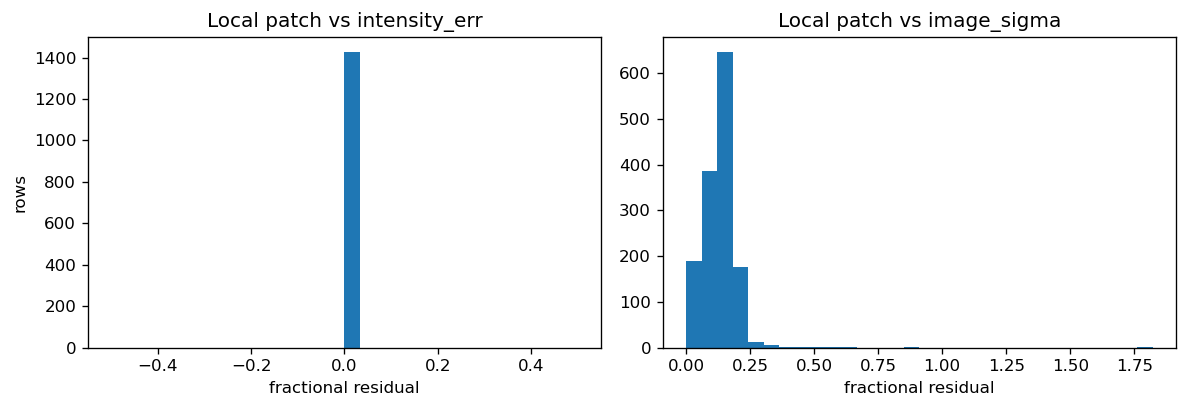

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].hist(parity_rows['frac_local_vs_intensity_err_residual'], bins=30)
axes[0].set_title('Local patch vs intensity_err')
axes[0].set_xlabel('fractional residual')
axes[0].set_ylabel('rows')

axes[1].hist(parity_rows['frac_local_vs_image_sigma_residual'], bins=30)
axes[1].set_title('Local patch vs image_sigma')
axes[1].set_xlabel('fractional residual')

fig.tight_layout()

## Stage 03 Trap-Free Noise Map

The map samples trap-free local patches using the source-equivalent `histogram_around_point(size=35)` convention, which is an interior `34 x 34` slice in the current implementation.

In [5]:
noise_summary = pd.read_csv(cache / '03_noise_map_summary.csv')
display(noise_summary.head())

pd.Series({
    'temperature_quadrant_groups': len(noise_summary),
    'min_trap_free_count': noise_summary['trap_free_count'].min(),
    'total_trap_free_samples': noise_summary['trap_free_count'].sum(),
    'median_trap_free_sigma': noise_summary['trap_free_median'].median(),
    'median_trap_free_over_detected_local': noise_summary['trap_free_vs_detected_local_median_ratio'].median(),
    'median_trap_free_over_detected_global': noise_summary['trap_free_vs_detected_global_median_ratio'].median(),
})

,producing_stage,produced_at,temperature_K,quadrant,trap_free_count,trap_free_median,trap_free_p16,trap_free_p84,trap_free_p01,trap_free_p99,...,detected_local_count,detected_local_median,detected_local_p16,detected_local_p84,detected_global_count,detected_global_median,detected_global_p16,detected_global_p84,trap_free_vs_detected_local_median_ratio,trap_free_vs_detected_global_median_ratio
0,03_trap_free_noise_map,2026-05-20T12:50:26-07:00,125,0,5400,176.402309,169.936281,187.523104,162.663250,381.083181,...,23832,175.676424,169.280524,188.025440,1324,199.134276,199.134276,199.134276,1.004132,0.885846
1,03_trap_free_noise_map,2026-05-20T12:50:26-07:00,125,1,5400,213.400211,204.662155,233.305730,195.952371,389.489839,...,28836,213.191756,204.370026,229.262813,1602,244.188779,244.188779,244.188779,1.000978,0.873915
2,03_trap_free_noise_map,2026-05-20T12:50:26-07:00,125,2,5400,217.422934,209.323375,238.300764,200.802191,353.032430,...,19224,218.448579,210.024969,239.959314,1068,264.253596,264.253596,264.253596,0.995305,0.822781
3,03_trap_free_noise_map,2026-05-20T12:50:26-07:00,125,3,5400,175.151279,168.906035,187.239827,161.634748,276.436559,...,21186,174.849335,168.966012,187.090084,1177,210.996372,210.996372,210.996372,1.001727,0.830115
4,03_trap_free_noise_map,2026-05-20T12:50:26-07:00,130,0,5400,179.923249,173.456963,191.095162,165.799538,386.631231,...,23832,179.246754,172.671359,190.531363,1324,203.856043,203.856043,203.856043,1.003774,0.882600


temperature_quadrant_groups                  92.000000
min_trap_free_count                        5400.000000
total_trap_free_samples                  577200.000000
median_trap_free_sigma                      182.184198
median_trap_free_over_detected_local          0.935886
median_trap_free_over_detected_global         0.832796
dtype: float64

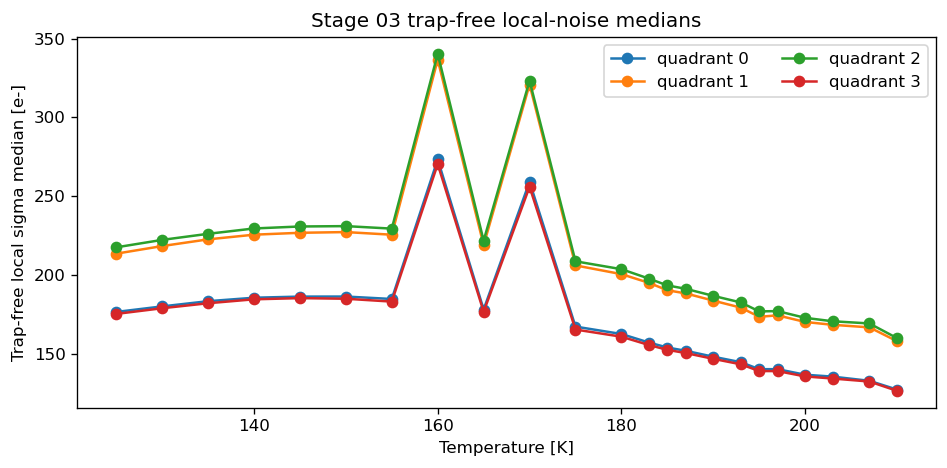

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
for q, group in noise_summary.groupby('quadrant'):
    ax.plot(group['temperature_K'], group['trap_free_median'], marker='o', label=f'quadrant {q}')
ax.set_xlabel('Temperature [K]')
ax.set_ylabel('Trap-free local sigma median [e-]')
ax.set_title('Stage 03 trap-free local-noise medians')
ax.legend(ncol=2)
fig.tight_layout()

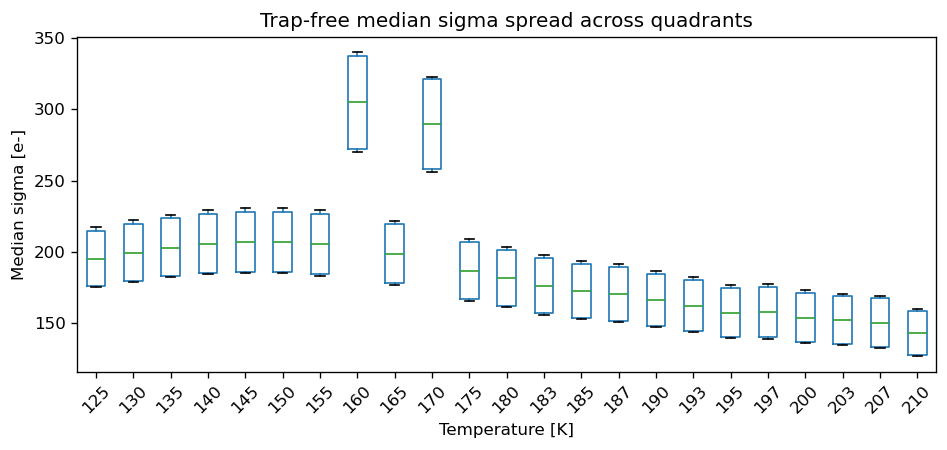

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
noise_summary.boxplot(column='trap_free_median', by='temperature_K', ax=ax, grid=False, rot=45)
ax.set_title('Trap-free median sigma spread across quadrants')
ax.set_xlabel('Temperature [K]')
ax.set_ylabel('Median sigma [e-]')
fig.suptitle('')
fig.tight_layout()

In [8]:
noise_h5 = cache / '03_noise_map_v1.h5'
with h5py.File(noise_h5, 'r') as h5:
    print('Top-level groups:', list(h5.keys()))
    if 'metadata' in h5.attrs:
        print(h5.attrs['metadata'])
    # Show the structure without loading the full file into memory.
    def visitor(name, obj):
        if isinstance(obj, h5py.Dataset):
            print(name, obj.shape, obj.dtype)
    h5.visititems(visitor)

Top-level groups: ['samples', 'summary']
samples/col (577200,) int16
samples/dtph (577200,) int64
samples/patch_half_width (577200,) int8
samples/quadrant (577200,) int8
samples/row (577200,) int16
samples/sigma (577200,) float32
samples/source_fits (577200,) object
samples/temperature_K (577200,) int16
summary/detected_global_count (92,) int64
summary/detected_global_median (92,) float64
summary/detected_global_p16 (92,) float64
summary/detected_global_p84 (92,) float64
summary/detected_local_count (92,) int64
summary/detected_local_median (92,) float64
summary/detected_local_p16 (92,) float64
summary/detected_local_p84 (92,) float64
summary/produced_at (92,) object
summary/producing_stage (92,) object
summary/quadrant (92,) int64
summary/temperature_K (92,) int64
summary/trap_free_count (92,) int64
summary/trap_free_max (92,) float64
summary/trap_free_median (92,) float64
summary/trap_free_min (92,) float64
summary/trap_free_p01 (92,) float64
summary/trap_free_p16 (92,) float64
summa